In [ ]:
import polars as pl
import re
from datetime import datetime
import plotly.express as px

# setup functions

In [3]:
# Define the regex pattern to match the line format and capture the relevant fields
# Of the semi-structured text data downloaded from Wikipedia - 
# https://en.wikipedia.org/wiki/List_of_Buffy_the_Vampire_Slayer_episodes
pattern = re.compile(
    r"""
    ^\s*
    (?P<n1>\d+)\s+
    (?P<n2>\d+)\s+
    (?P<n3>\d+)\s+
    "(?P<quoted>[^"]+)"\s+
    (?P<text1>[^\t]*)\t(?P<text1b>[^\t]*)\s+
    (?P<date>[A-Za-z]+\s+\d{1,2},\s+\d{4})\s+
    (?P<text2>.*)
    $
    """,
    re.VERBOSE
)

# read a line and parse it using the regex pattern, returning a dictionary of the captured fields
def parse_line(line):
    m = pattern.match(line)
    if not m:
        return None  # or raise error

    d = m.groupdict()

    # Convert types
    d["n1"] = int(d["n1"])
    d["n2"] = int(d["n2"])
    d["n3"] = int(d["n3"])
    d["date"] = datetime.strptime(d["date"], "%B %d, %Y")

    return d

# create a dataframe

In [119]:
# read the text and create a polars dataframe
header = []
rows = []

with open("Episode information.txt") as f:
    for lineno, line in enumerate(f, start=1):
        if lineno == 1:
            header = line.split()
            continue

        parsed = parse_line(line)
        if parsed:
            rows.append(parsed)

# make a df
df = pl.DataFrame(rows)
# set the column names
df.columns = header
# change viewers to a numeric
df = df.with_columns(
    # remove the fluff from the Viewers column and make it numeric
    pl.col("Viewers")
    .str.replace(r"\[\d+\]", "")  
    .cast(pl.Float64)
    .alias("Viewers"),
    # change Release date to an actual date type
    pl.col("Release").cast(pl.Date)
)

if type(df) == pl.DataFrame:
    df = df.to_pandas()  # Plotly works well with pandas DataFrames
    
print(df.head())
print(df.columns)

   Series  Number  Episode                               Title  \
0       1       1        1            Welcome to the Hellmouth   
1       1       2        2                         The Harvest   
2       1       3        3                               Witch   
3       1       4        4                       Teacher's Pet   
4       1       5        5  Never Kill a Boy on the First Date   

               Director                       Writer    Release  Viewers  
0  Charles Martin Smith                  Joss Whedon 1997-03-10     4.59  
1     John T. Kretchmer                  Joss Whedon 1997-03-10     4.59  
2         Stephen Cragg                  Dana Reston 1997-03-17     4.63  
3      Bruce Seth Green              David Greenwalt 1997-03-24     2.98  
4           David Semel  Rob Des Hotel & Dean Batali 1997-03-31     4.09  
Index(['Series', 'Number', 'Episode', 'Title', 'Director', 'Writer', 'Release',
       'Viewers'],
      dtype='object')


# Plot data

# Plot examples - multiple libraries

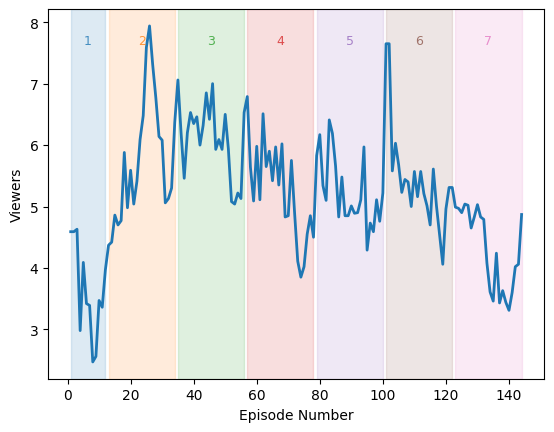

In [5]:
import matplotlib.pyplot as plt

pdf = df.sort("Number").to_pandas()

fig, ax = plt.subplots()

# Main line
ax.plot(pdf["Number"], pdf["Viewers"], linewidth=2)

# Get distinct series in order
series_list = sorted(pdf["Series"].unique())

# Use a colormap
cmap = plt.get_cmap("tab10")

for i, series in enumerate(series_list):
    group = pdf[pdf["Series"] == series]
    
    xmin = group["Number"].min()
    xmax = group["Number"].max()
    xmid = (xmin + xmax) / 2
    
    colour = cmap(i % 10)
    
    # Shade band
    ax.axvspan(xmin, xmax, alpha=0.15, color=colour)
    
    # Label in the middle of the band
    ax.text(
        xmid,
        ax.get_ylim()[1] * 0.95,   # near top
        f"{series}",
        ha="center",
        va="top",
        fontsize=9,
        color=colour,
        alpha=0.8
    )

ax.set_xlabel("Episode Number")
ax.set_ylabel("Viewers")

plt.show()

In [10]:
import altair as alt

chart = alt.Chart(df).mark_line(point=True).encode(
    x="Number:Q",
    y="Viewers:Q",
    color="Series:N",
    tooltip=["Title", "Episode", "Series", "Viewers"]
)

chart

alt.Chart(...)

In [13]:
base = alt.Chart(df)

bands = base.mark_rect(opacity=0.1).encode(
    x="min(Number):Q",
    x2="max(Number):Q",
    color="Series:N"
).transform_aggregate(
    min_Number="min(Number)",
    max_Number="max(Number)",
    groupby=["Series"]
)

line = base.mark_line(point=True).encode(
    x="Number:Q",
    y="Viewers:Q",
    tooltip=["Title", "Episode", "Series", "Viewers"]
)

bands + line

alt.LayerChart(...)

# Plotly Express for streamlit

In [ ]:
# Define lists for series, adversaries, hover text, and colors
list_series = [1,2,3,4,5,6,7]
list_adversaries = ["The Master", "Angelus", "Mayor Wilkins", "Adam", "Glorificus", "The Trio", "The First"]
list_hover = ["Series", "Episode", "Title"]
list_colours = ['orange', 'green', 'blue', 'brown', 'red', 'purple', 'grey']

# y axis limits with some padding
ymin = df["Viewers"].min() - 1
ymax = df["Viewers"].max() + 2 

# series start dates and episode numbers
series_starts = (
    df.groupby("Series")
      .agg(
          start_ep=("Number", "min"),
          final_ep=("Number", "max"),
          start_date=("Release", "min"),
      )
      .reset_index()
      .sort_values("Series")
)

# build customised tick marks for the x axis
list_start = series_starts["start_ep"].tolist()
list_final = series_starts["final_ep"].tolist()
list_ticks_date = [date.strftime("%B %Y") for date in series_starts["start_date"].tolist()]
list_ticks_text = [f"Ep. {n}-{f}<br>{d}" for n, f, d in zip(list_start, list_final, list_ticks_date )]

In [167]:
# Make the plot with Plotly Express, using the custom hover data and y axis limits

# Step 1. Basic chart
fig = px.line(
    df,
    x="Number",
    y="Viewers",
    title = 'Buffy the Vampire Slayer: Viewers per Episode',
    labels = {"Number": "Episode Number and Release Date", 
              "Viewers": "Viewers (millions)"},
    custom_data = list_hover, # for use later in a custom hover template
    range_y=[ymin, ymax]
)

# Step 2. Add vertical bands for each series, with annotations
for series in list_series:
    group = df[df["Series"] == series]
    
    xmin = group["Number"].min()
    xmax = group["Number"].max()
    
    fig.add_vrect(
        x0=xmin,
        x1=xmax,
        fillcolor = list_colours[series -1],
        opacity=0.1,
        line_width=0,
        annotation_text= f"Series {series}<br>{list_adversaries[series -1]}", # Format as HTML
        annotation_position="inside top", # Positions the text
    )

# Step 3. Customise x axis ticks
fig.update_xaxes(
    tickmode='array',
    tickvals=list_ticks_number,
    ticktext=list_ticks_text,
    tickangle=0.1
)

# Step 4. Customise hover template and line style
fig.update_traces(
    mode="lines+markers",
    line_color='#786FB0', line_width=3,
    hovertemplate = "Episode %{customdata[0]}-%{customdata[1]} : %{customdata[2]}"
)

# Step 5. Customise overall layout
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",

    hoverlabel=dict(
        bgcolor="white",
        font_size=14
    )
)

# Final step. Show the figure
fig.show()

In [175]:
df['Director'].value_counts()

Director
James A. Contner        20
Joss Whedon             20
David Solomon           19
David Grossman          13
Michael Gershman        10
Bruce Seth Green         8
Nick Marck               7
James Whitmore, Jr.      5
David Greenwalt          4
David Semel              4
Michael Lange            4
Douglas Petrie           3
John T. Kretchmer        2
Ellen S. Pressman        2
Rick Rosenthal           2
Marti Noxon              2
Marita Grabiak           2
Dan Attias               2
David Fury               2
Reza Badiyi              1
Stephen Cragg            1
Charles Martin Smith     1
Scott Brazil             1
Stephen Posey            1
Deran Sarafian           1
Christopher Hibler       1
Regis Kimble             1
Tucker Gates             1
Turi Meyer               1
Bill L. Norton           1
Alan J. Levi             1
Michael Grossman         1
Name: count, dtype: int64

In [177]:
df['Writer'].value_counts()

Writer
Joss Whedon                                                                 23
Marti Noxon                                                                 20
Jane Espenson                                                               15
Douglas Petrie                                                              13
David Fury                                                                  12
Rebecca Rand Kirshner                                                        8
Drew Z. Greenberg                                                            6
Steven S. DeKnight                                                           5
David Greenwalt                                                              5
Rob Des Hotel & Dean Batali                                                  4
Tracey Forbes                                                                3
Drew Goddard                                                                 3
Dan Vebber                                   

In [180]:

filter_var = 'Writer'
filter_value = 'Noxon'

if filter_var == 'Director':
    df_highlight = df[df["Director"].str.contains(filter_value, case=False, na=False)]
elif filter_var == 'Writer':
    df_highlight = df[df["Writer"].str.contains(filter_value, case=False, na=False)]

import plotly.graph_objects as go
import copy

fig2 = copy.deepcopy(fig)
fig2.add_trace(
    go.Scatter(
        x=df_highlight["Number"],
        y=df_highlight["Viewers"],
        mode="markers",
        marker=dict(color="red", size=10),
        customdata=df_highlight[list_hover],
        hovertemplate = "Episode %{customdata[0]}-%{customdata[1]} : %{customdata[2]}",
        name=f"{filter_var} : {filter_value}",
    )
)

fig2.show()

# Save for later

In [ ]:
directors = sorted(df["Director"].drop_nulls().unique())
writers = sorted(df["Writer"].drop_nulls().unique())

selected_director = st.selectbox("Director", ["All"] + directors)
selected_writer = st.selectbox("Writer", ["All"] + writers)

filtered_df = df

if selected_director != "All":
    filtered_df = filtered_df.filter(pl.col("Director") == selected_director)

if selected_writer != "All":
    filtered_df = filtered_df.filter(pl.col("Writer") == selected_writer)

for series in filtered_df["Series"].unique():
    group = filtered_df.filter(pl.col("Series") == series)
    
    xmin = group["Number"].min()
    xmax = group["Number"].max()
    
    fig.add_vrect(
        x0=xmin,
        x1=xmax,
        fillcolor="lightgrey",
        opacity=0.1,
        line_width=0,
    )

fig.show()

NameError: name 'st' is not defined